Add you import statements and the database connection statements in the below code block

Database file path: /course/data/CSE-578/dinofunworld.db

In [7]:
# import statements here
import sqlite3
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
%matplotlib inline

db_filename = "dinofunworld.db"
connect = sqlite3.connect(db_filename)
cursor = connect.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables_names = cursor.fetchall()
print(tables_names)
for name in tables_names:
    cursor.execute(f"SELECT * FROM {name[0]}")
    table_cols = [description[0] for description in cursor.description]
    print(table_cols)

[('checkin',), ('attraction',), ('sequences',)]
['index', 'visitorID', 'timestamp', 'attraction', 'duration', 'type']
['index', 'AttractionID', 'Name', 'Region', 'Category', 'type']
['index', 'visitorID', 'sequence']


**Question 1:**

Create and display a dendrogram of the trajectories of the 5 visitors specified above. The clustering algorithm used to create the dendrogram should use the average distance between points in a cluster.

**NOTE:**

* You can reuse the distance matrix from Assignment 3.
* Make sure to use the correct clustering algorithm.
* The dendrogram  should have the following parameters:
    * Title should be '**Dendrogram of Trajectories of 5 Visitors to the Park**'
    * xlabel should be '**Visitor ID**' and ylabel should be '**Distance**'.
* The plot must not have the following parameters,
    * do not set figure size
    * do not set font size or font-weight for titles and labels




{165316: {296394: 318, 404385: 329, 448990: 318, 1835254: 336}, 296394: {165316: 318, 404385: 303, 448990: 0, 1835254: 282}, 404385: {165316: 329, 296394: 303, 448990: 303, 1835254: 298}, 448990: {165316: 318, 296394: 0, 404385: 303, 1835254: 282}, 1835254: {165316: 336, 296394: 282, 404385: 298, 448990: 282}}
[[318 329 318 336]
 [318 303   0 282]
 [329 303 303 298]
 [318   0 303 282]
 [336 282 298 282]]


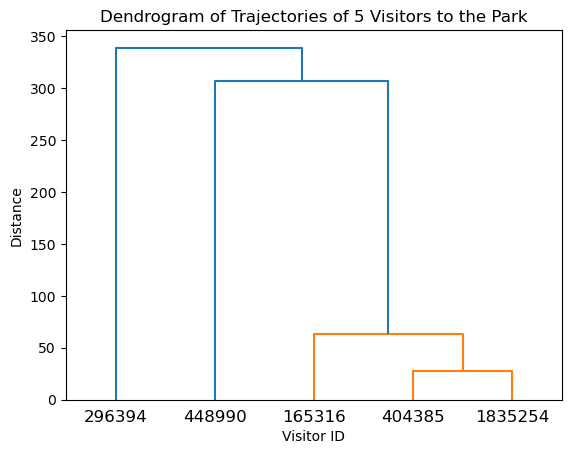

In [57]:
### TEST FUNCTION: test_question1
# DO NOT MODIFY OR REMOVE THE ABOVE LINE
# your code here
cursor.execute("SELECT visitorID, sequence FROM sequences WHERE visitorID in (165316, 1835254, 296394, 404385, 448990)")
sequence = cursor.fetchall()

dist_matrix_dict = {}
dist_matrix = []
ids = []
for i in range(len(sequence)):
    sub_dict = {}
    main_id_key = sequence[i][0]
    ids.append(main_id_key)
    for j in range(len(sequence)):
        sub_id_key = sequence[j][0]
        if main_id_key != sub_id_key:
            sequence1_pruned = np.asarray([int(k) for k in sequence[i][1].split('-')])
            sequence2_pruned = np.asarray([int(k) for k in sequence[j][1].split('-')])
            distance = np.sum(abs(np.subtract(sequence1_pruned, sequence2_pruned)) != 0)
            sub_dict[sub_id_key] = distance
            dist_matrix_dict[main_id_key] = sub_dict
            dist_matrix.append(distance)
print(dist_matrix_dict)
X = np.matrix(dist_matrix).reshape(-1,4)
print(X)
links = linkage(X, method = 'average')
dendrogram(links, labels = ids)
plt.xlabel('Visitor ID')
plt.ylabel('Distance')
plt.title('Dendrogram of Trajectories of 5 Visitors to the Park')
plt.show()